Цей ноутбук – навчальний проєкт у межах курсу GoIT з аналізу даних з використанням Python.

**Дані**: Stack Overflow Developer Survey (офіційне опитування розробників у 2025 році).

**Мета**: попрактикувати аналіз даних з використанням Python на основі реального датасету опитування розробників.

### Підготовка даних

У цьому розділі я підключаю бібліотеки для аналізу даних, завантажую основні результати опитування та таблицю з описом питань (schema). Переглядаю розмір датасету та перші рядки обох таблиць, щоб отримати базове уявлення про структуру даних і переконатися, що файли коректно зчитуються.

In [204]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Імпортую бібліотеки.
Завантажую два CSV-файли з результатами опитування та схемою запитань. Для коректного зчитування типів даних використовую параметр low_memory=False

Датасет містить 49 191 рядок і 172 колонки.

In [205]:
data_link1_survey_results_public = 'survey_results_public.csv'
data_link2_survey_results_schema = 'survey_results_schema.csv'

df_public_results = pd.read_csv(data_link1_survey_results_public, encoding="utf-8", low_memory=False)
schema = pd.read_csv(data_link2_survey_results_schema, encoding="utf-8")

df_public_results.shape

(49191, 172)

Переглянула базову інформацію про датафрейм за допомогою df.info(), порахувала кількість пропусків у кожній колонці та подивилась перші рядки через df.head().

In [206]:
df_public_results.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49191 entries, 0 to 49190
Columns: 172 entries, ResponseId to JobSat
dtypes: float64(52), int64(1), object(119)
memory usage: 64.6+ MB


In [207]:
df_public_results.isna().sum()

ResponseId                 0
MainBranch                 0
Age                        0
EdLevel                 1042
Employment               852
                       ...  
AIAgentExtWrite        48332
AIHuman                19997
AIOpen                 26651
ConvertedCompYearly    25244
JobSat                 22521
Length: 172, dtype: int64

У більшості колонок є пропуски. Водночас ключовий ідентифікатор респондента (ResponseId) заповнений повністю.

In [208]:
df_public_results.isna().sum().sort_values(ascending=False).head(10)

AIAgentObsWrite         48927
SOTagsWant Entry        48761
SOTagsHaveEntry         48733
AIModelsWantEntry       48716
AIAgentOrchWrite        48713
JobSatPoints_15_TEXT    48527
AIAgentKnowWrite        48425
AIModelsHaveEntry       48415
SO_Actions_15_TEXT      48368
AIAgentExtWrite         48332
dtype: int64

Окремо вивела топ-10 колонок з найбільшою кількістю пропусків, щоб зрозуміти, які поля потенційно потребують видалення або спеціальної обробки.

In [209]:
df_public_results.head(3)

,ResponseId,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,...,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,"Caring for dependents (children, elderly, etc.)",8.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,Vertex AI,NaN,NaN,NaN,ChatGPT,NaN,When I don’t trust AI’s answers,"Troubleshooting, profiling, debugging",61256.0,10.0
1,2,I am a developer by profession,25-34 years old,"Associate degree (A.A., A.S., etc.)",Employed,NaN,2.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers;When I want to...,All skills. AI is a flop.,104413.0,9.0
2,3,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Independent contractor, freelancer, or self-em...",None of the above,10.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,ChatGPT;Claude Code;GitHub Copilot;Google Gemini,NaN,When I don’t trust AI’s answers;When I want to...,"Understand how things actually work, problem s...",53061.0,8.0


Перші рядки допомогли побачити, як виглядають категоріальні значення, формат віку, зарплати тощо.

In [210]:
len(schema)

139

Таблиця schema містить опис кожної колонки в основних даних: який це блок опитування, як формулюється питання і який тип відповіді. Це допомагає розуміти значення в кожній колонці.

In [211]:
schema.head(5)

,qid,qname,question,type,sub,sq_id
0,QID18,TechEndorse_1,What attracts you to a technology or causes yo...,RO,AI integration or AI Agent capabilities,1.0
1,QID18,TechEndorse_2,What attracts you to a technology or causes yo...,RO,Easy-to-use API,2.0
2,QID18,TechEndorse_3,What attracts you to a technology or causes yo...,RO,Robust and complete API,3.0
3,QID18,TechEndorse_4,What attracts you to a technology or causes yo...,RO,Customizable and manageable codebase,4.0
4,QID18,TechEndorse_5,What attracts you to a technology or causes yo...,RO,Reputation for quality,5.0


### Підрахунок загальної кількості респондентів

**Мета**: Визначити загальну кількість респондентів, які взяли участь в опитуванні Stack Overflow.

Для цього я використовую поле ResponseId і рахую кількість унікальних значень.

In [212]:
#  nunique() рахує кількість унікальних значень.
total_respondents = df_public_results['ResponseId'].nunique()
total_respondents

49191

Підтвердила, що в опитуванні взяли участь 49191 унікальний респондент (за полем ResponseId). Таким чином я підтвердила, що кількість рядків у датасеті збігається з кількістю унікальних респондентів, тобто немає дублікатів по ResponseId.

### Аналіз повноти відповідей респондентів

**Мета**: Визначити кількість респондентів, що відповіли на всі запитання опитування.

Для цього:
1. Взяла список назв запитань (qname) з таблиці schema.
2. Знайшла перетин цих назв з реально наявними колонками основного датасету.
3. Побудувала з них окремий датафрейм df_questions (49 191 респондент і 126 запитань).
4. Перевірила, чи є респонденти, в чиїх відповідях немає жодного пропуску (NaN). Для цього використала df_questions.notna().all(axis=1).

In [213]:
questions_list = set(schema['qname'])

cols_set = set(df_public_results.columns)

common_questions = questions_list & cols_set
# спільні колонки, які є і в schema, і в основному датасеті

questions_list = list(common_questions)
questions_list

df_questions = df_public_results[questions_list]
df_questions.shape
df_questions.head(3)

# тепер df_questions це табличка, де кожен рядок - це всі респонденти, але серед колонок тільки питання з опитувальника
# результат вивів 0 рядків. Тому наступним перевіряю, чи є рядки без жодного пропущеного значення

mask_full = df_questions.notna().all(axis=1)
total_full = mask_full.sum() 
print(f'Непорожні рядки: {total_full}')

Непорожні рядки: 0


**Результат:** жоден респондент не відповів на всі 126 колонок із відповідями (змінних, що відповідають питанням опитування), тобто повністю заповнених анкет немає. Це типова ситуація для великих анкет, де частина запитань є необовʼязковими. Для аналізу це означає, що не можна спиратися лише на повністю заповнені анкети і логічно працювати з пропусками в окремих питаннях (колонках), а не відкидати респондентів цілком.

Такий результат також показує, що ця анкета може бути занадто довгою для частини респондентів, тому при створенні майбутніх опитувань варто або скорочувати кількість запитань, або розділяти їх на блоки для комфорту користувачів.

### Статистичний аналіз досвіду респондентів

**Мета**: Обчислити міри центральної тенденції для поля WorkExp (досвід роботи респондентів).

Я розраховую середнє значення (mean), медіану (median) та моду (mode) для WorkExp, щоб побачити типовий рівень досвіду серед учасників опитування. Колонка WorkExp в цій версії датасету вже містить числові значення, тому перетворення в числовий тип не потребує. Результат подаю у вигляді невеликої таблиці з трьома показниками.

In [214]:
WorkExp_mean = df_public_results['WorkExp'].mean()
WorkExp_mode = df_public_results['WorkExp'].mode()[0]
WorkExp_median = df_public_results['WorkExp'].median()

workexp_stats_df = pd.DataFrame({
    'metric': ['mean', 'median', 'mode'],
    'value': [round(WorkExp_mean, 2), WorkExp_median, WorkExp_mode]
})

workexp_stats_df

,metric,value
0,mean,13.37
1,median,10.00
2,mode,10.00


**Результат:** середній досвід роботи респондентів становить близько 13 років, медіана 10 років, а найчастіше зустрічається значення 10 років. Тобто серед респондентів найбільше спеціалістів, які мають приблизно 10 років досвіду, але є група респондентів із дуже великим стажем, яка тягне середнє значення вгору.

Отже, опитування здебільшого відображає думку досвідчених спеціалістів, а не студентів/джунів.

### Аналіз віддаленої роботи

**Мета**: Визначити кількість респондентів, які працюють віддалено (remote).

Знаходжу колонку, яка відповідає за формат роботи (RemoteWork), відфільтровую респондентів із значенням 'Remote' у цій колонці та підраховую кількість таких записів.

Інформація про формат роботи зберігається в колонці RemoteWork.

In [215]:
remote_count = df_public_results[df_public_results['RemoteWork'] == 'Remote']
remote_count_workers = len(remote_count)
remote_share = len(remote_count) / len(df_public_results) * 100
print(f'Кількість респондентів, які працюють віддалено: {remote_count_workers}, приблизно {round(remote_share, 2)} % вибірки.') 

# Remote_Workers.shape повертає кортеж (кількість_рядків, кількість_стовпців).

Кількість респондентів, які працюють віддалено: 10931, приблизно 22.22 % вибірки.


**Результат:** Майже чверть респондентів працює повністю віддалено. Отже, формат remote є звичним для помітної частини розробників. Під час аналізу ринку праці варто розглядати віддалених спеціалістів окремо, адже у них можуть бути власні очікування щодо формату роботи та умов.

### Визначення популярності Python

**Мета**: Обчислити відсоток респондентів, які програмують на Python.

Для цього: 
1. Використовую колонку LanguageHaveWorkedWith, де перелічені мови програмування, з якими працювали респонденти.
2. Нормалізую текст (переводжу в нижній регістр, заповнюю пропуски порожнім рядком), знаходжу всі рядки, де згадується 'python', підраховую їх кількість і обчислюю частку від загальної кількості респондентів.

In [216]:
LanguageChoice = df_public_results['LanguageHaveWorkedWith'].str.lower().fillna('')


python_pos = LanguageChoice.str.contains('python')
python_count = has_python.sum()
Percentage_python = python_count / len(df_public_results) * 100

print(round(Percentage_python, 2))

37.54


**Результат:** відсоток респондентів, які програмують на Python, становить 37.54 % (приблизно кожен третій). Це підтверджує, що Python залишається однією з найпопулярніших мов програмування, тому попит на курси та вакансії з Python стабільно високий.

### Аналіз шляхів навчання програмуванню

**Мета**: Визначити, скільки респондентів навчалося програмувати за допомогою онлайн-курсів.

Для цього: 
1. Використовую колонку LearnCode, де описані способи навчання, перевожу її в нижній регістр.
2. Шукаю згадку про online courses or certification.
3. Підраховую кількість респондентів, які обрали цей варіант.

In [217]:
learncode_lower = df_public_results['LearnCode'].str.lower().fillna('')

online_pos = learncode_lower.str.find('online courses or certification')
has_online_courses = online_pos != -1

online_count = has_online_courses.sum()

print(f'Кількість респондентів, які навчалися програмувати за допомогою онлайн-курсів: {online_count}')


Кількість респондентів, які навчалися програмувати за допомогою онлайн-курсів: 10973


**Результат:** онлайн-курси є популярним шляхом навчання програмуванню. Для роботодавців це означає, що значна частина розробників приходить саме з онлайн-навчання, а не з університетів.

### Географічний аналіз компенсації Python-розробників

**Мета**:  Серед респондентів, що програмують на Python, проаналізувати річну компенсацію (ConvertedCompYearly) в розрізі країн.

Для цього: 
1. Відбираю тільки тих респондентів, у яких є Python серед мов, з якими вони працюють.
2. Беру поля Country та ConvertedCompYearly і прибираю рядки з пропусками хоча б в одному з цих полів.
3. За допомогою groupby розраховую для кожної країни середню та медіанну річну суму. Суми наведені в тисячах доларів на рік.
4. Щоб уникнути викривлень результатів через дуже маленькі вибірки, залишаю лише країни, де є щонайменше 20 Python-респондентів.
5. У підсумковій таблиці кожен рядок відповідає окремій країні, а стовпці Mean і Median містять відповідні значення компенсації.
6. Додатково візуалізувала топ-10 країн з найвищою компенсацією Python-розробників: побудувала горизонтальну стовпчикову діаграму для порівняння середньої та медіанної компенсаціями між країнами.

In [218]:
df_python = df_public_results[has_python]

df_py_comp = df_python[['Country', 'ConvertedCompYearly']].dropna()

metric_results = (
    df_py_comp
    .groupby('Country')['ConvertedCompYearly']
    .agg(Mean='mean', Median='median', Count='size')
    .round(2)
)

metric_filtered = metric_results[metric_results['Count'] >= 20].copy()

metric_filtered[['Mean', 'Median']] = (
    metric_filtered[['Mean', 'Median']] / 1000
).round(1)

top10_countries = (
    metric_filtered
    .sort_values('Median', ascending=False)
    .head(10)
)

top10_countries

,Mean,Median,Count
Country,,,
United States of America,173.3,150.0,3126
Switzerland,156.5,142.6,240
Israel,135.8,142.6,104
Ireland,120.5,116.0,74
Denmark,115.7,98.3,120
Australia,118.1,97.5,307
United Kingdom of Great Britain and Northern Ireland,117.7,95.0,750
Singapore,147.5,91.4,41
Norway,104.7,89.4,88


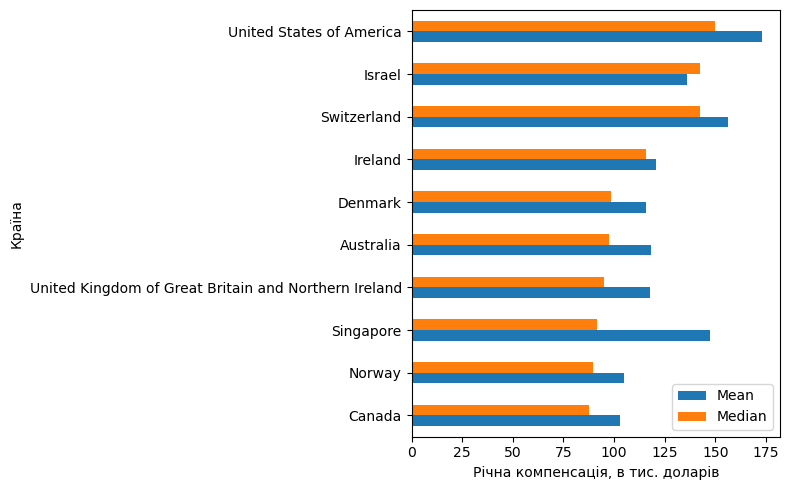

In [219]:

top10_countries_sorted = top10_countries.sort_values('Median')

top10_countries_sorted[['Mean', 'Median']].plot(
    kind='barh',
    figsize=(8, 5)
)

plt.xlabel('Річна компенсація, в тис. доларів')
plt.ylabel('Країна')
plt.tight_layout()
plt.show()


**Результат:** найбільшу медіанну річну компенсацію Python-розробників мають респонденти зі Сполучених Штатів, Ізраїлю, Швейцарії та Ірландії. Це країни з високими зарплатами в галузі, де ринок особливо конкурентний. 

Найбільший розрив між середнім та медіаною спостерігається у Сінгапурі, що може вказувати на наявність кількох дуже високих зарплат, які тягнуть середнє значення вгору.

### Аналіз освіти найбільш оплачуваних спеціалістів

**Мета**: Визначити, чи пов’язаний рівень формальної освіти з рівнем компенсації.

Для цього:
1. Відбираю з датасету колонки ConvertedCompYearly та EdLevel.
2. Прибираю рядки без зазначеної компенсації, групую за рівнем освіти.
3. Визначаю середнє, медіану та кількість людей у групах (щоб відкинути групи з надто малою кількістю спостережень).
4. Округлюю результати метрик. Суми наведені в тисячах доларів на рік.
5. Сортую рівні освіти за спаданням медіанної компенсації і виводжу результати у вигляді таблиці. Додатково візуалізую результати у вигляді горизонтальної стовпчикової діаграми для порівняння середньої та медіанної компенсації.

In [220]:
salary_by_education = (
    df_public_results[['ConvertedCompYearly', 'EdLevel']]
    .dropna(subset=['ConvertedCompYearly'])
    .groupby('EdLevel')['ConvertedCompYearly']
    .agg(Mean='mean', Median='median', Count='size')
    .sort_values('Median', ascending=False)
    .reset_index()
)

salary_by_education_filtered = salary_by_education[salary_by_education['Count'] >= 30]
salary_by_education_filtered[['Mean', 'Median']] = (
    salary_by_education_filtered[['Mean', 'Median']] / 1000).round(1)

salary_by_education_filtered

,EdLevel,Mean,Median,Count
0,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)",128.2,87.0,1363
1,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",105.1,80.0,6918
2,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",98.2,75.7,10425
3,"Associate degree (A.A., A.S., etc.)",169.0,69.7,798
4,Some college/university study without earning ...,87.7,66.0,2862
5,"Secondary school (e.g. American high school, G...",71.2,52.2,1215
6,Other (please specify):,89.8,49.9,222
7,Primary/elementary school,137.0,46.6,127


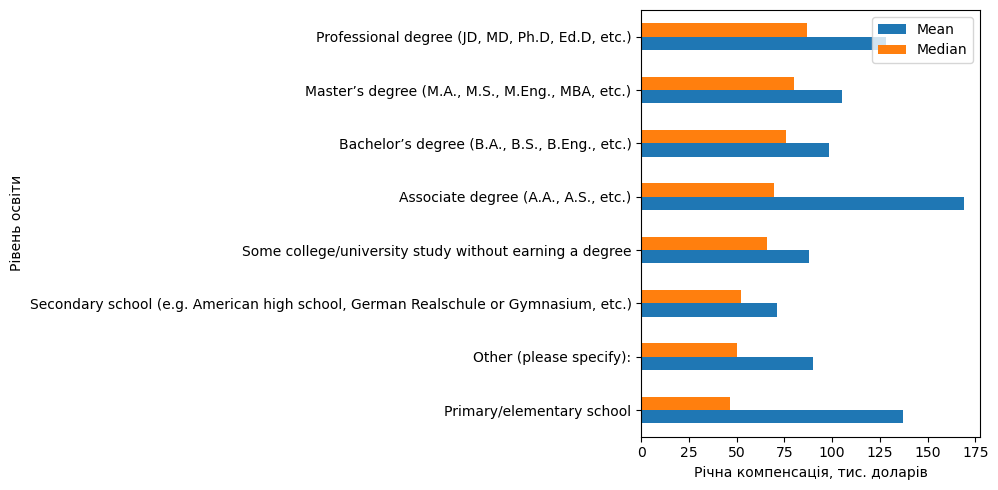

In [221]:
salary_by_education_filtered.sort_values('Median').plot(
    x='EdLevel',
    y=['Mean', 'Median'],
    kind='barh',
    figsize=(10, 5)
)

plt.xlabel('Річна компенсація, тис. доларів')
plt.ylabel('Рівень освіти')
plt.tight_layout()
plt.show()


**Результат:** медіанна компенсація зростає разом з рівнем освіти. Найбільше заробляють фахівці з професійним ступнем (JD, MD, Ph.D, Ed тощо), трохи менше магістри, далі йдуть бакалаври. Люди з неповною вищею або середньою освітою в середньому отримують суттєво менше.

Середні значення місцями дуже відрізняються від медіани. Наприклад, в Associate degree та Primary/elementary school (дуже високе середнє, але нижча медіана), що вказує на наявність кількох дуже високих зарплат в окремих невеликих групах. Медіана краще описує типову компенсацію.

Отже, згідно результатів опитування респондентів, формальна освіта пов'язана з рівнем доходу, хоча сам по собі диплом не гарантує високу компенсацію.

### Підсумкові висновки

В цьому ноутбуці я проаналізувала дані опитування розробників 2025 року від Stack Overflow: понад 49 000 респондентів зі 177 країн, 62 основні питання та додаткові, загалом 126 позицій у схемі. Я дивилася на заповненість анкет, досвід роботи, використання Python, формат роботи (remote), навчання через онлайн-курси, а також компенсацію в розрізі країн та рівнів освіти.

В результаті аналізу я виявила, що жоден респондент не відповів на всі запитання анкети; середній досвід роботи становить близько 13 років, а медіанний 10 років. Тобто опитування більше представляє досвідчених спеціалістів, а не джунів. Приблизно 22 % респондентів працюють повністю віддалено, а 37.54 % зазначили, що протягом останнього року працювали з Python. Багато учасників користуються онлайн-курсами як одним із способів навчання програмуванню. Найвищу медіанну річну компенсацію серед Python-розробників мають респонденти зі США, Ізраїлю, Швейцарії та Ірландії. Загалом медіанна компенсація зростає разом із рівнем формальної освіти: найбільше заробляють фахівці з професійним ступенем (JD, MD, PhD, EdD тощо), трохи менше магістри, далі йдуть бакалаври.